In [1]:
from datetime import datetime, UTC
from urllib.parse import urlencode
from urllib.request import urlopen
from urllib.error import HTTPError, URLError
import json

BASE_URL = "https://api.kraken.com"


def to_datetime(timestamp: int) -> str:
    return datetime.fromtimestamp(timestamp, UTC).strftime(
        "%Y-%m-%d %H:%M:%S UTC"
    )


def get_ohlc(pair="BTC/USD", interval=1440, since=None):
    """
    Fetch OHLC candles from Kraken.

    Intervals:
        1      = 1 minute
        5      = 5 minutes
        15     = 15 minutes
        30     = 30 minutes
        60     = 1 hour
        240    = 4 hours
        1440   = 1 day
        10080  = 1 week
        21600  = 15 days
    """

    params = {
        "pair": pair,
        "interval": interval,
    }

    if since is not None:
        params["since"] = since

    url = f"{BASE_URL}/0/public/OHLC?{urlencode(params)}"

    try:
        with urlopen(url) as response:
            payload = json.load(response)

        if payload["error"]:
            raise RuntimeError(payload["error"])

        result = payload["result"]

        # Pair key is dynamic
        pair_key = next(k for k in result.keys() if k != "last")

        candles = []

        for candle in result[pair_key]:
            candles.append({
                "timestamp": candle[0],
                "datetime": to_datetime(candle[0]),
                "open": float(candle[1]),
                "high": float(candle[2]),
                "low": float(candle[3]),
                "close": float(candle[4]),
                "vwap": float(candle[5]),
                "volume": float(candle[6]),
                "trades": int(candle[7]),
            })

        return candles

    except HTTPError as e:
        raise RuntimeError(f"HTTP error: {e.code}") from e

    except URLError as e:
        raise RuntimeError(f"Connection error: {e.reason}") from e


if __name__ == "__main__":
    daily_btc = get_ohlc(
        pair="BTC/USD",
        interval=1440,   # daily candles
    )

    data = json.dumps(daily_btc, indent=2)

In [3]:
import pandas as pd

# create dataframe
df = pd.DataFrame(json.loads(data))

# convert datetime column to pandas datetime
df["datetime"] = pd.to_datetime(df["datetime"])

print(df.head())

    timestamp                  datetime     open     high      low    close  \
0  1716940800 2024-05-29 00:00:00+00:00  68325.0  68843.3  67100.0  67575.4   
1  1717027200 2024-05-30 00:00:00+00:00  67575.4  69550.0  67099.9  68365.0   
2  1717113600 2024-05-31 00:00:00+00:00  68365.0  69000.0  66652.4  67498.1   
3  1717200000 2024-06-01 00:00:00+00:00  67498.1  67817.9  67383.3  67717.2   
4  1717286400 2024-06-02 00:00:00+00:00  67717.2  68379.9  67283.0  67729.1   

      vwap       volume  trades  
0  67781.8  1916.841463   21965  
1  68503.7  2098.190112   25159  
2  67756.6  1214.317517   22910  
3  67655.1   262.429155    9996  
4  67858.9   686.528337   12673  


In [5]:
df.drop(["timestamp", "vwap", "trades"], axis = 1, inplace = True)

df.head()

,datetime,open,high,low,close,volume
0,2024-05-29 00:00:00+00:00,68325.0,68843.3,67100.0,67575.4,1916.841463
1,2024-05-30 00:00:00+00:00,67575.4,69550.0,67099.9,68365.0,2098.190112
2,2024-05-31 00:00:00+00:00,68365.0,69000.0,66652.4,67498.1,1214.317517
3,2024-06-01 00:00:00+00:00,67498.1,67817.9,67383.3,67717.2,262.429155
4,2024-06-02 00:00:00+00:00,67717.2,68379.9,67283.0,67729.1,686.528337


In [12]:
df_2025 = df[df["datetime"].dt.year == 2025]

df_2025

,datetime,open,high,low,close,volume
217,2025-01-01 00:00:00+00:00,93370.8,94888.0,92588.1,94380.8,576.162219
218,2025-01-02 00:00:00+00:00,94380.9,97719.9,94167.2,96805.2,1727.878345
219,2025-01-03 00:00:00+00:00,96805.3,98888.0,96034.1,98111.1,1520.228296
220,2025-01-04 00:00:00+00:00,98111.1,98714.8,97548.4,98208.9,630.752662
221,2025-01-05 00:00:00+00:00,98208.9,98750.0,97250.0,98306.2,437.304342
...,...,...,...,...,...,...
577,2025-12-27 00:00:00+00:00,87303.6,87913.3,87177.5,87802.6,416.750639
578,2025-12-28 00:00:00+00:00,87814.4,87998.9,87364.3,87853.3,659.230112
579,2025-12-29 00:00:00+00:00,87865.9,90298.9,86700.0,87135.1,2800.129273
580,2025-12-30 00:00:00+00:00,87135.1,89298.0,86736.5,88401.9,1179.549828


In [13]:
df_2025 = df_2025.reset_index(drop = True)
df_2025

,datetime,open,high,low,close,volume
0,2025-01-01 00:00:00+00:00,93370.8,94888.0,92588.1,94380.8,576.162219
1,2025-01-02 00:00:00+00:00,94380.9,97719.9,94167.2,96805.2,1727.878345
2,2025-01-03 00:00:00+00:00,96805.3,98888.0,96034.1,98111.1,1520.228296
3,2025-01-04 00:00:00+00:00,98111.1,98714.8,97548.4,98208.9,630.752662
4,2025-01-05 00:00:00+00:00,98208.9,98750.0,97250.0,98306.2,437.304342
...,...,...,...,...,...,...
360,2025-12-27 00:00:00+00:00,87303.6,87913.3,87177.5,87802.6,416.750639
361,2025-12-28 00:00:00+00:00,87814.4,87998.9,87364.3,87853.3,659.230112
362,2025-12-29 00:00:00+00:00,87865.9,90298.9,86700.0,87135.1,2800.129273
363,2025-12-30 00:00:00+00:00,87135.1,89298.0,86736.5,88401.9,1179.549828


In [14]:
df_2025["candle_body"] = df_2025["close"] - df_2025["open"]
df_2025

,datetime,open,high,low,close,volume,candle_body
0,2025-01-01 00:00:00+00:00,93370.8,94888.0,92588.1,94380.8,576.162219,1010.0
1,2025-01-02 00:00:00+00:00,94380.9,97719.9,94167.2,96805.2,1727.878345,2424.3
2,2025-01-03 00:00:00+00:00,96805.3,98888.0,96034.1,98111.1,1520.228296,1305.8
3,2025-01-04 00:00:00+00:00,98111.1,98714.8,97548.4,98208.9,630.752662,97.8
4,2025-01-05 00:00:00+00:00,98208.9,98750.0,97250.0,98306.2,437.304342,97.3
...,...,...,...,...,...,...,...
360,2025-12-27 00:00:00+00:00,87303.6,87913.3,87177.5,87802.6,416.750639,499.0
361,2025-12-28 00:00:00+00:00,87814.4,87998.9,87364.3,87853.3,659.230112,38.9
362,2025-12-29 00:00:00+00:00,87865.9,90298.9,86700.0,87135.1,2800.129273,-730.8
363,2025-12-30 00:00:00+00:00,87135.1,89298.0,86736.5,88401.9,1179.549828,1266.8


In [16]:
df_2025["target"] = (df_2025["candle_body"] > 0).astype(int)
df_2025

,datetime,open,high,low,close,volume,candle_body,target
0,2025-01-01 00:00:00+00:00,93370.8,94888.0,92588.1,94380.8,576.162219,1010.0,1
1,2025-01-02 00:00:00+00:00,94380.9,97719.9,94167.2,96805.2,1727.878345,2424.3,1
2,2025-01-03 00:00:00+00:00,96805.3,98888.0,96034.1,98111.1,1520.228296,1305.8,1
3,2025-01-04 00:00:00+00:00,98111.1,98714.8,97548.4,98208.9,630.752662,97.8,1
4,2025-01-05 00:00:00+00:00,98208.9,98750.0,97250.0,98306.2,437.304342,97.3,1
...,...,...,...,...,...,...,...,...
360,2025-12-27 00:00:00+00:00,87303.6,87913.3,87177.5,87802.6,416.750639,499.0,1
361,2025-12-28 00:00:00+00:00,87814.4,87998.9,87364.3,87853.3,659.230112,38.9,1
362,2025-12-29 00:00:00+00:00,87865.9,90298.9,86700.0,87135.1,2800.129273,-730.8,0
363,2025-12-30 00:00:00+00:00,87135.1,89298.0,86736.5,88401.9,1179.549828,1266.8,1


In [18]:
from sklearn.preprocessing import StandardScaler

features = ["open", "high", "low", "close", "volume", "candle_body"]

train = df_2025[df_2025["datetime"] < "2025-10-01"]
test = df_2025[df_2025["datetime"] >= "2025-10-01"]

scaler = StandardScaler()

train[features] = scaler.fit_transform(train[features])
test[features] = scaler.transform(test[features])

In [19]:
train

,datetime,open,high,low,close,volume,candle_body,target
0,2025-01-01 00:00:00+00:00,-0.761834,-0.775336,-0.672228,-0.680526,-0.888909,0.445966,1
1,2025-01-02 00:00:00+00:00,-0.674558,-0.526510,-0.538820,-0.471222,0.145348,1.120892,1
2,2025-01-03 00:00:00+00:00,-0.465081,-0.423875,-0.381098,-0.358481,-0.041124,0.587127,1
3,2025-01-04 00:00:00+00:00,-0.352255,-0.439093,-0.253165,-0.350038,-0.839886,0.010651,1
4,2025-01-05 00:00:00+00:00,-0.343805,-0.436000,-0.278375,-0.341638,-1.013605,0.010412,1
...,...,...,...,...,...,...,...,...
268,2025-09-26 00:00:00+00:00,0.592887,0.583658,0.687058,0.642558,-0.100270,0.277271,1
269,2025-09-27 00:00:00+00:00,0.649620,0.531439,0.729308,0.643784,-1.217492,-0.029292,1
270,2025-09-28 00:00:00+00:00,0.650838,0.760530,0.733346,0.851612,-0.857938,1.112779,1
271,2025-09-29 00:00:00+00:00,0.858838,0.940267,0.936326,1.044772,-0.513575,1.031700,1


In [20]:
test

,datetime,open,high,low,close,volume,candle_body,target
273,2025-10-01 00:00:00+00:00,1.020170,1.317666,1.134279,1.410363,-0.029460,2.161507,1
274,2025-10-02 00:00:00+00:00,1.418059,1.519782,1.503750,1.587344,0.371554,0.942222,1
275,2025-10-03 00:00:00+00:00,1.595186,1.776524,1.588706,1.726304,0.396747,0.732057,1
276,2025-10-04 00:00:00+00:00,1.734253,1.680997,1.780483,1.740713,-0.830429,0.043626,1
277,2025-10-05 00:00:00+00:00,1.748673,1.929331,1.833708,1.837034,-0.018710,0.496408,1
...,...,...,...,...,...,...,...,...
360,2025-12-27 00:00:00+00:00,-1.286062,-1.388169,-1.129333,-1.248437,-1.032062,0.202109,1
361,2025-12-28 00:00:00+00:00,-1.241927,-1.380648,-1.113551,-1.244060,-0.814312,-0.017457,1
362,2025-12-29 00:00:00+00:00,-1.237477,-1.178558,-1.169674,-1.306063,1.108245,-0.384770,0
363,2025-12-30 00:00:00+00:00,-1.300621,-1.266502,-1.166590,-1.196698,-0.347058,0.568515,1


In [21]:
import pandas as pd

df = df_2025.copy()

features = ["open", "high", "low", "close", "volume", "candle_body"]

lags = 5

for col in features:
    for lag in range(1, lags + 1):
        df[f"{col}_lag{lag}"] = df[col].shift(lag)

In [22]:
df

,datetime,open,high,low,close,volume,candle_body,target,open_lag1,open_lag2,...,volume_lag1,volume_lag2,volume_lag3,volume_lag4,volume_lag5,candle_body_lag1,candle_body_lag2,candle_body_lag3,candle_body_lag4,candle_body_lag5
0,2025-01-01 00:00:00+00:00,93370.8,94888.0,92588.1,94380.8,576.162219,1010.0,1,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-01-02 00:00:00+00:00,94380.9,97719.9,94167.2,96805.2,1727.878345,2424.3,1,93370.8,NaN,...,576.162219,NaN,NaN,NaN,NaN,1010.0,NaN,NaN,NaN,NaN
2,2025-01-03 00:00:00+00:00,96805.3,98888.0,96034.1,98111.1,1520.228296,1305.8,1,94380.9,93370.8,...,1727.878345,576.162219,NaN,NaN,NaN,2424.3,1010.0,NaN,NaN,NaN
3,2025-01-04 00:00:00+00:00,98111.1,98714.8,97548.4,98208.9,630.752662,97.8,1,96805.3,94380.9,...,1520.228296,1727.878345,576.162219,NaN,NaN,1305.8,2424.3,1010.0,NaN,NaN
4,2025-01-05 00:00:00+00:00,98208.9,98750.0,97250.0,98306.2,437.304342,97.3,1,98111.1,96805.3,...,630.752662,1520.228296,1727.878345,576.162219,NaN,97.8,1305.8,2424.3,1010.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
360,2025-12-27 00:00:00+00:00,87303.6,87913.3,87177.5,87802.6,416.750639,499.0,1,87183.0,87613.7,...,1634.021445,574.284927,1468.668881,1607.291637,2230.946989,120.6,-415.7,197.3,-1134.1,-79.5
361,2025-12-28 00:00:00+00:00,87814.4,87998.9,87364.3,87853.3,659.230112,38.9,1,87303.6,87183.0,...,416.750639,1634.021445,574.284927,1468.668881,1607.291637,499.0,120.6,-415.7,197.3,-1134.1
362,2025-12-29 00:00:00+00:00,87865.9,90298.9,86700.0,87135.1,2800.129273,-730.8,0,87814.4,87303.6,...,659.230112,416.750639,1634.021445,574.284927,1468.668881,38.9,499.0,120.6,-415.7,197.3
363,2025-12-30 00:00:00+00:00,87135.1,89298.0,86736.5,88401.9,1179.549828,1266.8,1,87865.9,87814.4,...,2800.129273,659.230112,416.750639,1634.021445,574.284927,-730.8,38.9,499.0,120.6,-415.7


In [23]:
df = df.dropna().reset_index(drop=True)

In [24]:
df

,datetime,open,high,low,close,volume,candle_body,target,open_lag1,open_lag2,...,volume_lag1,volume_lag2,volume_lag3,volume_lag4,volume_lag5,candle_body_lag1,candle_body_lag2,candle_body_lag3,candle_body_lag4,candle_body_lag5
0,2025-01-06 00:00:00+00:00,98306.3,102479.6,97974.0,102222.0,2276.110660,3915.7,1,98208.9,98111.1,...,437.304342,630.752662,1520.228296,1727.878345,576.162219,97.3,97.8,1305.8,2424.3,1010.0
1,2025-01-07 00:00:00+00:00,102222.0,102759.3,96100.0,96932.2,2322.871228,-5289.8,0,98306.3,98208.9,...,2276.110660,437.304342,630.752662,1520.228296,1727.878345,3915.7,97.3,97.8,1305.8,2424.3
2,2025-01-08 00:00:00+00:00,96932.2,97232.8,92501.0,95060.4,2675.626976,-1871.8,0,102222.0,98306.3,...,2322.871228,2276.110660,437.304342,630.752662,1520.228296,-5289.8,3915.7,97.3,97.8,1305.8
3,2025-01-09 00:00:00+00:00,95060.1,95251.1,91168.5,92531.7,2567.921950,-2528.4,0,96932.2,102222.0,...,2675.626976,2322.871228,2276.110660,437.304342,630.752662,-1871.8,-5289.8,3915.7,97.3,97.8
4,2025-01-10 00:00:00+00:00,92523.5,95771.2,92200.0,94698.8,2409.344824,2175.3,1,95060.1,96932.2,...,2567.921950,2675.626976,2322.871228,2276.110660,437.304342,-2528.4,-1871.8,-5289.8,3915.7,97.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,2025-12-27 00:00:00+00:00,87303.6,87913.3,87177.5,87802.6,416.750639,499.0,1,87183.0,87613.7,...,1634.021445,574.284927,1468.668881,1607.291637,2230.946989,120.6,-415.7,197.3,-1134.1,-79.5
356,2025-12-28 00:00:00+00:00,87814.4,87998.9,87364.3,87853.3,659.230112,38.9,1,87303.6,87183.0,...,416.750639,1634.021445,574.284927,1468.668881,1607.291637,499.0,120.6,-415.7,197.3,-1134.1
357,2025-12-29 00:00:00+00:00,87865.9,90298.9,86700.0,87135.1,2800.129273,-730.8,0,87814.4,87303.6,...,659.230112,416.750639,1634.021445,574.284927,1468.668881,38.9,499.0,120.6,-415.7,197.3
358,2025-12-30 00:00:00+00:00,87135.1,89298.0,86736.5,88401.9,1179.549828,1266.8,1,87865.9,87814.4,...,2800.129273,659.230112,416.750639,1634.021445,574.284927,-730.8,38.9,499.0,120.6,-415.7


In [25]:
df["target"] = df["target"].shift(-1)
df = df.dropna().reset_index(drop=True)

In [26]:
df

,datetime,open,high,low,close,volume,candle_body,target,open_lag1,open_lag2,...,volume_lag1,volume_lag2,volume_lag3,volume_lag4,volume_lag5,candle_body_lag1,candle_body_lag2,candle_body_lag3,candle_body_lag4,candle_body_lag5
0,2025-01-06 00:00:00+00:00,98306.3,102479.6,97974.0,102222.0,2276.110660,3915.7,0.0,98208.9,98111.1,...,437.304342,630.752662,1520.228296,1727.878345,576.162219,97.3,97.8,1305.8,2424.3,1010.0
1,2025-01-07 00:00:00+00:00,102222.0,102759.3,96100.0,96932.2,2322.871228,-5289.8,0.0,98306.3,98208.9,...,2276.110660,437.304342,630.752662,1520.228296,1727.878345,3915.7,97.3,97.8,1305.8,2424.3
2,2025-01-08 00:00:00+00:00,96932.2,97232.8,92501.0,95060.4,2675.626976,-1871.8,0.0,102222.0,98306.3,...,2322.871228,2276.110660,437.304342,630.752662,1520.228296,-5289.8,3915.7,97.3,97.8,1305.8
3,2025-01-09 00:00:00+00:00,95060.1,95251.1,91168.5,92531.7,2567.921950,-2528.4,1.0,96932.2,102222.0,...,2675.626976,2322.871228,2276.110660,437.304342,630.752662,-1871.8,-5289.8,3915.7,97.3,97.8
4,2025-01-10 00:00:00+00:00,92523.5,95771.2,92200.0,94698.8,2409.344824,2175.3,0.0,95060.1,96932.2,...,2567.921950,2675.626976,2322.871228,2276.110660,437.304342,-2528.4,-1871.8,-5289.8,3915.7,97.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
354,2025-12-26 00:00:00+00:00,87183.0,89484.6,86611.7,87303.6,1634.021445,120.6,1.0,87613.7,87416.4,...,574.284927,1468.668881,1607.291637,2230.946989,783.035840,-415.7,197.3,-1134.1,-79.5,284.1
355,2025-12-27 00:00:00+00:00,87303.6,87913.3,87177.5,87802.6,416.750639,499.0,1.0,87183.0,87613.7,...,1634.021445,574.284927,1468.668881,1607.291637,2230.946989,120.6,-415.7,197.3,-1134.1,-79.5
356,2025-12-28 00:00:00+00:00,87814.4,87998.9,87364.3,87853.3,659.230112,38.9,0.0,87303.6,87183.0,...,416.750639,1634.021445,574.284927,1468.668881,1607.291637,499.0,120.6,-415.7,197.3,-1134.1
357,2025-12-29 00:00:00+00:00,87865.9,90298.9,86700.0,87135.1,2800.129273,-730.8,1.0,87814.4,87303.6,...,659.230112,416.750639,1634.021445,574.284927,1468.668881,38.9,499.0,120.6,-415.7,197.3


In [28]:
#------------------------------

In [27]:
df = df_2025.copy()

In [29]:
df

,datetime,open,high,low,close,volume,candle_body,target
0,2025-01-01 00:00:00+00:00,93370.8,94888.0,92588.1,94380.8,576.162219,1010.0,1
1,2025-01-02 00:00:00+00:00,94380.9,97719.9,94167.2,96805.2,1727.878345,2424.3,1
2,2025-01-03 00:00:00+00:00,96805.3,98888.0,96034.1,98111.1,1520.228296,1305.8,1
3,2025-01-04 00:00:00+00:00,98111.1,98714.8,97548.4,98208.9,630.752662,97.8,1
4,2025-01-05 00:00:00+00:00,98208.9,98750.0,97250.0,98306.2,437.304342,97.3,1
...,...,...,...,...,...,...,...,...
360,2025-12-27 00:00:00+00:00,87303.6,87913.3,87177.5,87802.6,416.750639,499.0,1
361,2025-12-28 00:00:00+00:00,87814.4,87998.9,87364.3,87853.3,659.230112,38.9,1
362,2025-12-29 00:00:00+00:00,87865.9,90298.9,86700.0,87135.1,2800.129273,-730.8,0
363,2025-12-30 00:00:00+00:00,87135.1,89298.0,86736.5,88401.9,1179.549828,1266.8,1


In [30]:
df = df.sort_values("datetime").reset_index(drop=True)

In [31]:
df["future_return"] = df["close"].shift(-1) / df["close"] - 1

df["target"] = (df["future_return"] > 0).astype(int)

df = df.dropna().reset_index(drop=True)

In [32]:
df

,datetime,open,high,low,close,volume,candle_body,target,future_return
0,2025-01-01 00:00:00+00:00,93370.8,94888.0,92588.1,94380.8,576.162219,1010.0,1,0.025687
1,2025-01-02 00:00:00+00:00,94380.9,97719.9,94167.2,96805.2,1727.878345,2424.3,1,0.013490
2,2025-01-03 00:00:00+00:00,96805.3,98888.0,96034.1,98111.1,1520.228296,1305.8,1,0.000997
3,2025-01-04 00:00:00+00:00,98111.1,98714.8,97548.4,98208.9,630.752662,97.8,1,0.000991
4,2025-01-05 00:00:00+00:00,98208.9,98750.0,97250.0,98306.2,437.304342,97.3,1,0.039833
...,...,...,...,...,...,...,...,...,...
359,2025-12-26 00:00:00+00:00,87183.0,89484.6,86611.7,87303.6,1634.021445,120.6,1,0.005716
360,2025-12-27 00:00:00+00:00,87303.6,87913.3,87177.5,87802.6,416.750639,499.0,1,0.000577
361,2025-12-28 00:00:00+00:00,87814.4,87998.9,87364.3,87853.3,659.230112,38.9,0,-0.008175
362,2025-12-29 00:00:00+00:00,87865.9,90298.9,86700.0,87135.1,2800.129273,-730.8,1,0.014538


In [33]:
features_base = ["open", "high", "low", "close", "volume", "candle_body"]

lags = 5

df_lagged = df.copy()

for col in features_base:
    for lag in range(1, lags + 1):
        df_lagged[f"{col}_lag{lag}"] = df_lagged[col].shift(lag)

In [34]:
df_lagged = df_lagged.dropna().reset_index(drop=True)

In [35]:
target_col = "target"

feature_cols = [col for col in df_lagged.columns 
                if col not in ["datetime", "future_return", "target"]]

X = df_lagged[feature_cols]
y = df_lagged[target_col]

In [36]:
split = int(len(df_lagged) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [37]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [38]:
df_lagged.loc[X_test.index, "pred"] = model.predict(X_test)

In [40]:
df_lagged["position"] = df_lagged["pred"].map({1: 1, 0: -1})

In [41]:
df_lagged["strategy_return"] = df_lagged["position"] * df_lagged["future_return"]

In [42]:
df_lagged["equity_strategy"] = (1 + df_lagged["strategy_return"]).cumprod()

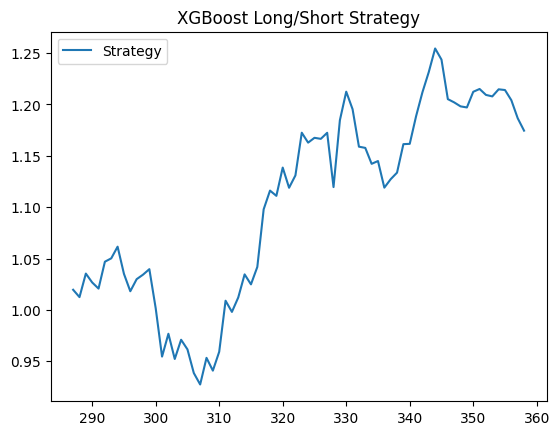

In [43]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df_lagged["equity_strategy"], label="Strategy")
plt.legend()
plt.title("XGBoost Long/Short Strategy")
plt.show()

In [45]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.5138888888888888
              precision    recall  f1-score   support

           0       0.57      0.53      0.55        40
           1       0.46      0.50      0.48        32

    accuracy                           0.51        72
   macro avg       0.51      0.51      0.51        72
weighted avg       0.52      0.51      0.52        72



In [46]:
df_lagged.columns

Index(['datetime', 'open', 'high', 'low', 'close', 'volume', 'candle_body',
       'target', 'future_return', 'open_lag1', 'open_lag2', 'open_lag3',
       'open_lag4', 'open_lag5', 'high_lag1', 'high_lag2', 'high_lag3',
       'high_lag4', 'high_lag5', 'low_lag1', 'low_lag2', 'low_lag3',
       'low_lag4', 'low_lag5', 'close_lag1', 'close_lag2', 'close_lag3',
       'close_lag4', 'close_lag5', 'volume_lag1', 'volume_lag2', 'volume_lag3',
       'volume_lag4', 'volume_lag5', 'candle_body_lag1', 'candle_body_lag2',
       'candle_body_lag3', 'candle_body_lag4', 'candle_body_lag5', 'pred',
       'position', 'strategy_return', 'equity_strategy'],
      dtype='str')